# Limpieza de Datos - Smart Lighting: Predicción de Consumo Energético

**Variable objetivo:** `energy_consumption_kwh` (regresión continua)

**Acciones basadas en el EDA:**
- Extraer features temporales desde `timestamp` (hora, mes, día semana, fin de semana, estación)
- Codificar variables categóricas: `day_of_week` y `time_of_day` con Ordinal Encoding; `weather_condition` con One-Hot Encoding
- Aplicar **Winsorizing** a outliers de `ambient_light_lux` y `occupancy_count`
- Revisar multicolinealidad y eliminar variables muy correlacionadas
- Estandarizar variables numéricas continuas
- `special_event_flag` se conserva (en cuerda floja, se deja para evaluar en el modelo)

## 1. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Cargar el dataset

In [6]:
df = pd.read_csv('../data/smart_lighting_dataset_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Dimensiones originales: {df.shape}')
df.head()

Dimensiones originales: (12000, 17)


,timestamp,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,weather_condition,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity,energy_consumption_kwh,lighting_action_class
0,2024-01-01 00:00:00,3,0.00,0,22.08,7,Monday,Night,Cloudy,0,3.83,3.27,26.0,4.54,54.40,1.144,0
1,2024-01-01 00:43:00,3,35.78,0,19.19,6,Monday,Night,Cloudy,0,4.61,1.50,18.9,2.42,89.75,2.069,1
2,2024-01-01 01:27:00,7,0.00,0,27.78,9,Monday,Night,Clear,0,4.21,2.51,27.6,2.85,82.25,1.687,1
3,2024-01-01 02:11:00,2,0.00,1,33.11,16,Monday,Night,Foggy,0,6.16,0.34,23.1,2.45,72.57,1.631,1
4,2024-01-01 02:55:00,4,0.00,1,27.07,11,Monday,Night,Clear,0,5.72,1.52,26.4,3.49,78.79,1.737,1


## 3. Extracción de features temporales desde `timestamp`

Se extraen features que capturan patrones de consumo:
- `hour`, `month`: granularidad horaria y mensual
- `is_weekend`: fin de semana vs día laboral
- `season`: estación del año (valor predictivo para iluminación)

> **Nota:** El EDA ya calculó `year`, `month`, `day`, `hour`, `dayofweek` durante el análisis temporal. Aquí se recalculan limpiamente y se agregan las nuevas. La columna `timestamp` se elimina al final.

In [7]:
# Recargar el dataset para garantizar que timestamp esté disponible como datetime
# (el EDA puede haber eliminado la columna o modificado el df en sesión)
df = pd.read_csv("../data/smart_lighting_dataset_2024.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extraer features temporales
df["hour"]       = df["timestamp"].dt.hour
df["month"]      = df["timestamp"].dt.month
df["is_weekend"] = df["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:  return 1  # Invierno
    elif month in [3, 4, 5]: return 2  # Primavera
    elif month in [6, 7, 8]: return 3  # Verano
    else:                    return 4  # Otoño

df["season"] = df["month"].apply(get_season)

# Eliminar timestamp (ya no se necesita)
df = df.drop(columns=["timestamp"])

print("Features temporales creadas: hour, month, is_weekend, season")
print(f"Dimensiones: {df.shape}")


Features temporales creadas: hour, month, is_weekend, season
Dimensiones: (12000, 20)


## 4. Codificación de variables categóricas

Según las observaciones del EDA:
- `day_of_week` → **Ordinal Encoding** (Lunes=1 … Domingo=7): tiene orden natural
- `time_of_day` → **Ordinal Encoding** (Morning=1, Afternoon=2, Evening=3, Night=4): tiene orden temporal
- `weather_condition` → **One-Hot Encoding**: categorías nominales sin orden

In [8]:
# Ver valores únicos antes de codificar
print('day_of_week:', df['day_of_week'].unique())
print('time_of_day:', df['time_of_day'].unique())
print('weather_condition:', df['weather_condition'].unique())

day_of_week: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
time_of_day: ['Night' 'Morning' 'Afternoon' 'Evening']
weather_condition: ['Cloudy' 'Clear' 'Foggy' 'Rainy']


In [9]:
# Ordinal Encoding: day_of_week (1=Lunes ... 7=Domingo)
day_order = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3,
             'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
df['day_of_week'] = df['day_of_week'].map(day_order)

# Ordinal Encoding: time_of_day (orden temporal del día)
time_order = {'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}
df['time_of_day'] = df['time_of_day'].map(time_order)

# One-Hot Encoding: weather_condition
df = pd.get_dummies(df, columns=['weather_condition'], drop_first=False, dtype=int)

print('Codificación aplicada correctamente.')
print(f'Dimensiones: {df.shape}')
print('\nColumnas weather generadas:', [c for c in df.columns if c.startswith('weather_')])

Codificación aplicada correctamente.
Dimensiones: (12000, 23)

Columnas weather generadas: ['weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']


## 5. Tratamiento de outliers con Winsorizing

El EDA identificó outliers en `ambient_light_lux` (0.28%) y `occupancy_count` (2.04%).

**Winsorizing** reemplaza los valores extremos por el valor del percentil límite (no los elimina). Esto preserva todas las filas y evita distorsiones en el modelo.

Se usa un límite del **1% en cada cola** (percentil 1 y 99).

In [10]:
# Ver distribución antes del Winsorizing
cols_winsorize = ['ambient_light_lux', 'occupancy_count']

print('Estadísticas ANTES del Winsorizing:')
print(df[cols_winsorize].describe().loc[['min', 'max', 'mean', 'std']].round(2))

Estadísticas ANTES del Winsorizing:
      ambient_light_lux  occupancy_count
min                0.00             0.00
max           105403.50           230.00
mean            3708.63             8.56
std             4656.28             8.27


In [11]:
# Aplicar Winsorizing al 1% en cada cola
for col in cols_winsorize:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

print('Estadísticas DESPUÉS del Winsorizing:')
print(df[cols_winsorize].describe().loc[['min', 'max', 'mean', 'std']].round(2))

Estadísticas DESPUÉS del Winsorizing:
      ambient_light_lux  occupancy_count
min                0.00             1.00
max            10410.87            24.00
mean            3575.49             8.24
std             3597.81             4.82


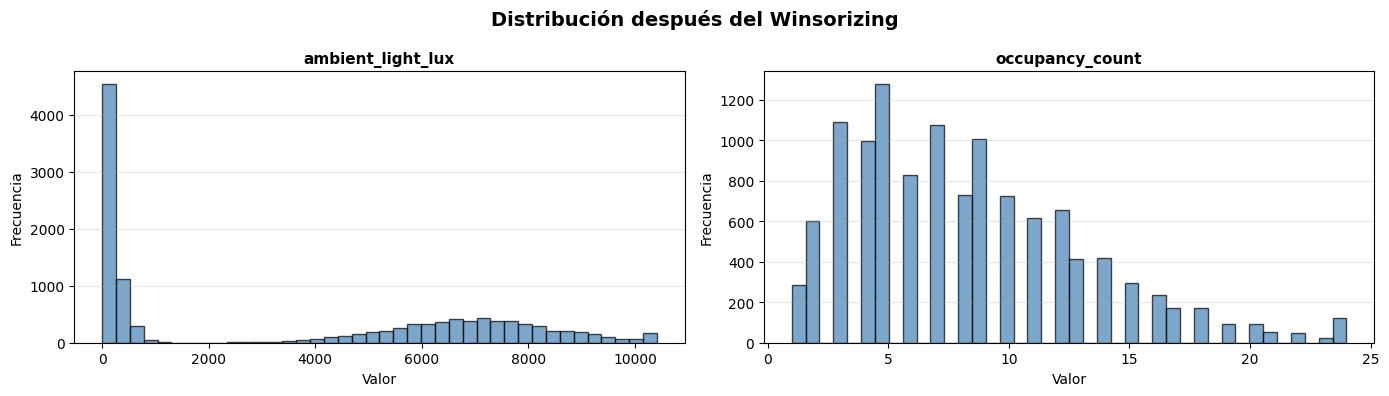

In [12]:
# Visualizar el efecto del Winsorizing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución después del Winsorizing', fontsize=14, fontweight='bold')

for idx, col in enumerate(cols_winsorize):
    axes[idx].hist(df[col], bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis de multicolinealidad

Del EDA se observó que `adjusted_light_intensity` tiene correlación de **0.919** con `energy_consumption_kwh`. Esto no es necesariamente un problema (es una feature valiosa), pero sí es importante revisar si hay variables **entre sí** altamente correlacionadas que aporten información redundante.

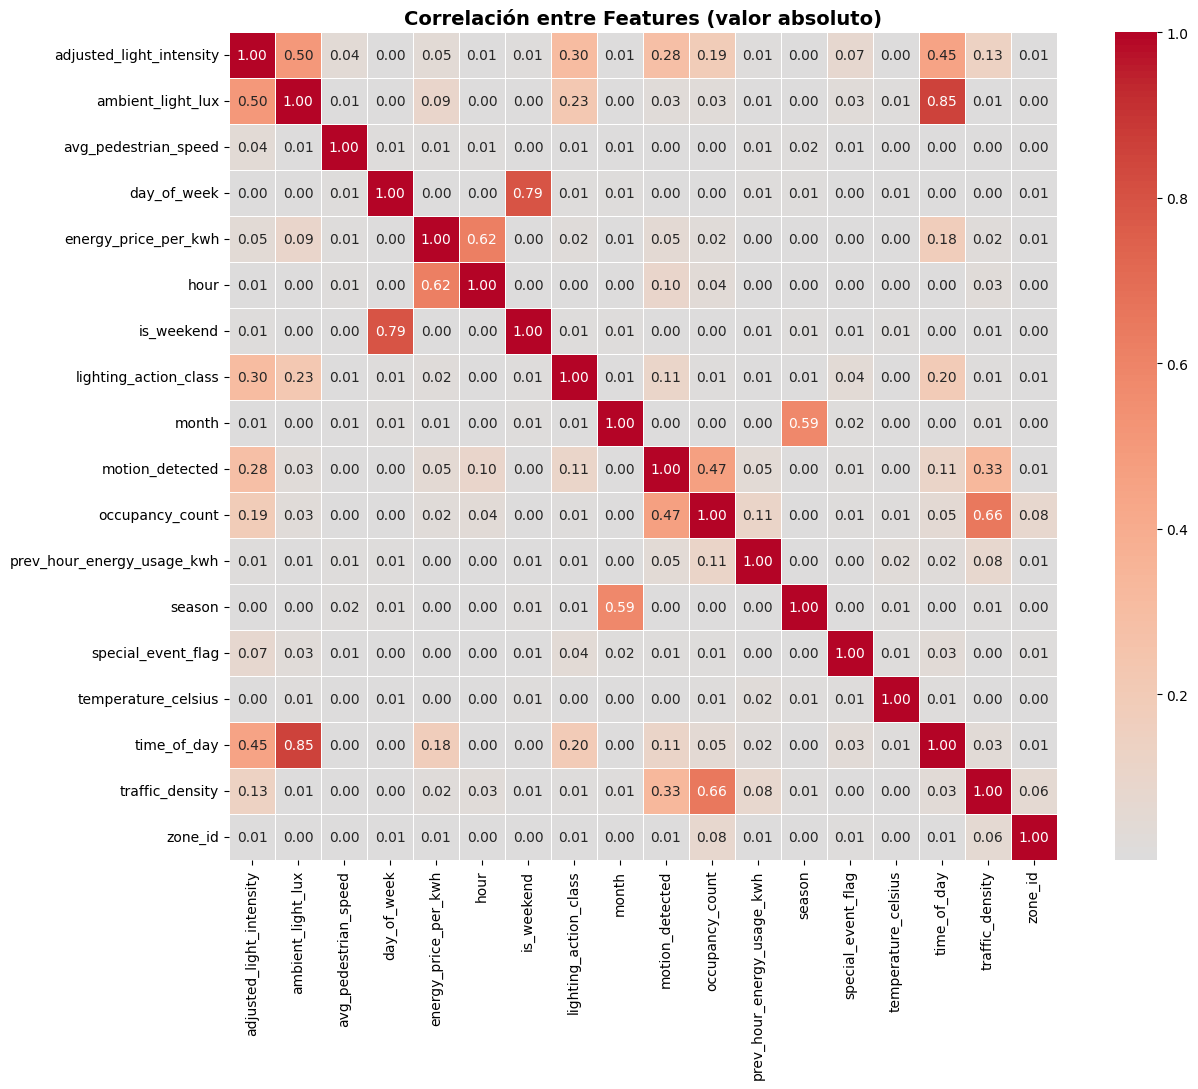

In [13]:
# Calcular matriz de correlación de variables numéricas (excluyendo OHE y target)
exclude = [c for c in df.columns if c.startswith('weather_')] + ['energy_consumption_kwh']
num_cols = df.select_dtypes(include=[np.number]).columns.difference(exclude).tolist()

corr_matrix = df[num_cols].corr().abs()

# Visualizar
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlación entre Features (valor absoluto)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Mostrar pares con correlación > 0.85 (umbral de multicolinealidad alta)
umbral = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pares_altos = [(col, row, upper.loc[row, col])
               for col in upper.columns
               for row in upper.index
               if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > umbral]

if pares_altos:
    print(f'Pares con correlación > {umbral}:')
    for v1, v2, corr_val in sorted(pares_altos, key=lambda x: -x[2]):
        print(f'  {v1}  ↔  {v2}  → {corr_val:.3f}')
else:
    print(f'No hay pares de features con correlación > {umbral}')

Pares con correlación > 0.85:
  time_of_day  ↔  ambient_light_lux  → 0.852


In [15]:
# Si se detectan pares altamente correlacionados, eliminar el de menor correlación con el target
# Ejemplo: si 'day_of_week' y 'dayofweek_num' tienen corr > 0.85, se elimina el menos relevante

# Verificar correlación de cada feature con el target para decidir cuál conservar
corr_con_target = df[num_cols + ['energy_consumption_kwh']].corr()['energy_consumption_kwh'].drop('energy_consumption_kwh')
print('Correlación de features con energy_consumption_kwh (ordenada):')
print(corr_con_target.abs().sort_values(ascending=False).round(4))

# NOTA: Si el análisis del paso anterior no encontró pares > 0.85,
# no se elimina ninguna columna en este paso.

Correlación de features con energy_consumption_kwh (ordenada):
adjusted_light_intensity      0.9189
ambient_light_lux             0.4414
time_of_day                   0.3891
motion_detected               0.3185
occupancy_count               0.2988
lighting_action_class         0.2798
traffic_density               0.2082
special_event_flag            0.0738
energy_price_per_kwh          0.0438
avg_pedestrian_speed          0.0385
prev_hour_energy_usage_kwh    0.0283
zone_id                       0.0156
hour                          0.0123
is_weekend                    0.0043
temperature_celsius           0.0042
season                        0.0028
day_of_week                   0.0004
month                         0.0003
Name: energy_consumption_kwh, dtype: float64


## 7. Estandarización de variables numéricas continuas

Se estandarizan las variables continuas. Se excluyen:
- Variables binarias: `motion_detected`, `special_event_flag`, `is_weekend`
- Variables discretas de tipo categórico: `zone_id`, `lighting_action_class`, `day_of_week`, `time_of_day`, `season`
- Columnas OHE (`weather_*`)
- Variable objetivo: `energy_consumption_kwh`

In [16]:
# Variables que NO se estandarizan
no_escalar = [
    'motion_detected', 'special_event_flag', 'is_weekend',
    'zone_id', 'lighting_action_class', 'day_of_week',
    'time_of_day', 'season', 'month', 'hour',
    'energy_consumption_kwh'
] + [c for c in df.columns if c.startswith('weather_')]

cols_escalar = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in no_escalar]

print('Columnas que se estandarizarán:')
print(cols_escalar)

Columnas que se estandarizarán:
['ambient_light_lux', 'temperature_celsius', 'occupancy_count', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity']


In [17]:
scaler = StandardScaler()
df[cols_escalar] = scaler.fit_transform(df[cols_escalar])

print('Verificación (media ≈ 0, std ≈ 1):')
df[cols_escalar].describe().loc[['mean', 'std']].round(4)

Verificación (media ≈ 0, std ≈ 1):


,ambient_light_lux,temperature_celsius,occupancy_count,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 8. Verificación final del dataset limpio

In [18]:
print('=== RESUMEN DEL DATASET LIMPIO ===')
print(f'Dimensiones: {df.shape}')
print(f'Valores faltantes totales: {df.isnull().sum().sum()}')
print(f'\nColumnas finales:')
print(df.columns.tolist())
print(f'\nTipos de datos:')
print(df.dtypes)

=== RESUMEN DEL DATASET LIMPIO ===
Dimensiones: (12000, 23)
Valores faltantes totales: 0

Columnas finales:
['zone_id', 'ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'special_event_flag', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity', 'energy_consumption_kwh', 'lighting_action_class', 'hour', 'month', 'is_weekend', 'season', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']

Tipos de datos:
zone_id                         int64
ambient_light_lux             float64
motion_detected                 int64
temperature_celsius           float64
occupancy_count               float64
day_of_week                     int64
time_of_day                     int64
special_event_flag              int64
energy_price_per_kwh          float64
prev_hour_energy_usage_kwh    float64
traffic_density        

In [19]:
print('Estadísticas de la variable objetivo:')
print(df['energy_consumption_kwh'].describe().round(4))

Estadísticas de la variable objetivo:
count    12000.0000
mean         1.4836
std          0.5382
min          0.0000
25%          1.0470
50%          1.5950
75%          1.9070
max          2.8870
Name: energy_consumption_kwh, dtype: float64


In [20]:
df.head()

,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,...,energy_consumption_kwh,lighting_action_class,hour,month,is_weekend,season,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Foggy,weather_condition_Rainy
0,3,-0.993840,0,-0.460746,-0.257032,1,4,0,-0.946558,0.399885,...,1.144,0,0,1,0,1,0,1,0,0
1,3,-0.983895,0,-0.922368,-0.464636,1,4,0,-0.333568,-0.576984,...,2.069,1,0,1,0,1,0,1,0,0
2,7,-0.993840,0,0.449719,0.158177,1,4,0,-0.647922,-0.019562,...,1.687,1,1,1,0,1,1,0,0,0
3,2,-0.993840,1,1.301084,1.611408,1,4,0,0.884553,-1.217192,...,1.631,1,2,1,0,1,0,0,1,0
4,4,-0.993840,1,0.336310,0.573386,1,4,0,0.538764,-0.565946,...,1.737,1,2,1,0,1,1,0,0,0


## 9. Guardar el dataset limpio

In [21]:
df.to_csv('../data/smart_lighting_limpio.csv', index=False)
print('Dataset limpio guardado en: ../data/smart_lighting_limpio.csv')

Dataset limpio guardado en: ../data/smart_lighting_limpio.csv


---
## Resumen de transformaciones realizadas

| Paso | Acción | Justificación |
|------|--------|---------------|
| 1 | Extraer `hour`, `month`, `is_weekend`, `season` desde `timestamp` | Captura patrones temporales de consumo |
| 2 | Ordinal Encoding a `day_of_week` y `time_of_day` | Tienen orden natural (días y momentos del día) |
| 3 | One-Hot Encoding a `weather_condition` | Categoría nominal sin orden |
| 4 | Winsorizing al 1% en `ambient_light_lux` y `occupancy_count` | Trata outliers sin eliminar filas |
| 5 | Análisis de multicolinealidad (umbral 0.85) | Evitar features redundantes |
| 6 | StandardScaler en variables continuas | Mejora convergencia del modelo de regresión |
| — | `special_event_flag` conservado | Se evalúa su impacto en el modelo |
| — | `adjusted_light_intensity` conservado | Alta correlación con target (0.919) = feature muy valiosa |
